In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers


In [8]:
# Generate data
X = np.linspace(-np.pi, np.pi, 1000)
y = np.sin(X)

# print few values
print("X:", X[:10].round(2))
print("y:", y[:10].round(2))

X: [-3.14 -3.14 -3.13 -3.12 -3.12 -3.11 -3.1  -3.1  -3.09 -3.08]
y: [-0.   -0.01 -0.01 -0.02 -0.03 -0.03 -0.04 -0.04 -0.05 -0.06]


In [9]:
# Build model
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(1,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
])

# Compile model
model.compile(
    optimizer='adam',
    loss='mse'
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Train model : took 30 seconds
history = model.fit(X, y, epochs=200, verbose=0)

In [24]:
# Predictions
y_pred = model.predict(X)

# print few values
print("X (feature):", X[:10].round(2))
print("y (actual) :", y[:10].round(3))
# Convert predictions to integers by rounding to the nearest whole number
integer_y_pred = [round(float(val),3) for val in y_pred[:10].flatten()]
print("y_pred     :", integer_y_pred)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
X (feature): [-3.14 -3.14 -3.13 -3.12 -3.12 -3.11 -3.1  -3.1  -3.09 -3.08]
y (actual) : [-0.    -0.006 -0.013 -0.019 -0.025 -0.031 -0.038 -0.044 -0.05  -0.057]
y_pred     : [-0.003, -0.009, -0.016, -0.022, -0.028, -0.034, -0.04, -0.046, -0.052, -0.058]


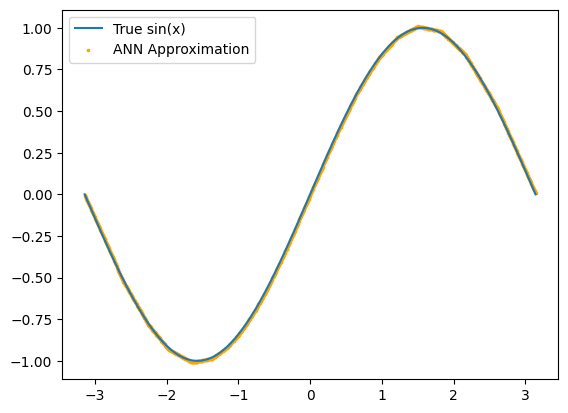

In [33]:
# Plot results

plt.figure()
plt.plot(X, y, label="True sin(x)")
plt.scatter(X, y_pred, label="ANN Approximation", marker='x', s=3, color='orange')
plt.legend()
plt.show()